# 00 - Data Preprocessing

Loads the raw dataset, cleans lyrics, encodes topic labels, and writes stratified train/test splits to `data/`.

## 1. Imports and setup

In [11]:
import os
import re
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT    = os.path.dirname(NOTEBOOK_DIR)
RAW_CSV      = os.path.join(REPO_ROOT, 'data', 'raw',
    'Music Dataset Lyrics and Metadata from 1950 to 2019 2', 'tcc_ceds_music.csv')
DATA_DIR     = os.path.join(REPO_ROOT, 'data', 'processed')
os.makedirs(DATA_DIR, exist_ok=True)

print('Raw CSV path:', RAW_CSV)
print('Output dir  :', DATA_DIR)

Raw CSV path: /Users/nidhijadhav/Desktop/cs4120/lyrics-to-valence/data/raw/Music Dataset Lyrics and Metadata from 1950 to 2019 2/tcc_ceds_music.csv
Output dir  : /Users/nidhijadhav/Desktop/cs4120/lyrics-to-valence/data/processed


## 2. Load raw CSV

In [12]:
df = pd.read_csv(RAW_CSV, index_col=0)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head(3)

Loaded 28,372 rows, 30 columns


,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,night/time,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0


In [13]:
print('Columns:', df.columns.tolist())
print('\nDtypes:')
print(df[['lyrics', 'topic', 'genre', 'release_date']].dtypes)
print('\nUnique topics:', sorted(df['topic'].dropna().unique()))

Columns: ['artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'like/girls', 'sadness', 'feelings', 'danceability', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy', 'topic', 'age']

Dtypes:
lyrics            str
topic             str
genre             str
release_date    int64
dtype: object

Unique topics: ['feelings', 'music', 'night/time', 'obscene', 'romantic', 'sadness', 'violence', 'world/life']


## 3. Drop rows with missing lyrics or topic

In [14]:
before = len(df)
df = df.dropna(subset=['lyrics', 'topic'])
df = df[df['lyrics'].str.strip().ne('')]
print(f'Dropped {before - len(df):,} rows with missing lyrics/topic. Remaining: {len(df):,}')

Dropped 0 rows with missing lyrics/topic. Remaining: 28,372


## 4. Drop duplicates

In [15]:
before = len(df)
df = df.drop_duplicates(subset=['lyrics'])
print(f'Dropped {before - len(df):,} duplicate rows. Remaining: {len(df):,}')

Dropped 0 duplicate rows. Remaining: 28,372


## 5. Filter out very short lyrics (< 100 characters)

In [16]:
before = len(df)
df = df[df['lyrics'].str.len() >= 100]
print(f'Dropped {before - len(df):,} songs with < 100 character lyrics. Remaining: {len(df):,}')

Dropped 580 songs with < 100 character lyrics. Remaining: 27,792


## 6. Text cleaning

Lowercase, collapse whitespace, and remove NLTK English stopwords.

In [17]:
def clean_lyrics(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()           # collapse whitespace
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS] # remove stopwords
    return ' '.join(tokens)

df['lyrics_clean'] = df['lyrics'].astype(str).apply(clean_lyrics)

print('Before cleaning — sample:')
print(df['lyrics'].iloc[0][:120])
print('\nAfter cleaning — sample:')
print(df['lyrics_clean'].iloc[0][:120])

Before cleaning — sample:
hold time feel break feel untrue convince speak voice tear try hold hurt try forgive okay play break string feel heart w

After cleaning — sample:
hold time feel break feel untrue convince speak voice tear try hold hurt try forgive okay play break string feel heart w


## 7. Encode topic labels

In [18]:
le = LabelEncoder()
df['topic_label'] = le.fit_transform(df['topic'])

label_map = {int(i): cls for i, cls in enumerate(le.classes_)}
map_path  = os.path.join(DATA_DIR, 'topic_label_map.json')
with open(map_path, 'w') as f:
    json.dump(label_map, f, indent=2)

print('Label encoding (alphabetical order):')
for k, v in label_map.items():
    print(f'  {k} → {v}')

Label encoding (alphabetical order):
  0 → feelings
  1 → music
  2 → night/time
  3 → obscene
  4 → romantic
  5 → sadness
  6 → violence
  7 → world/life


## 8. Class distribution plot

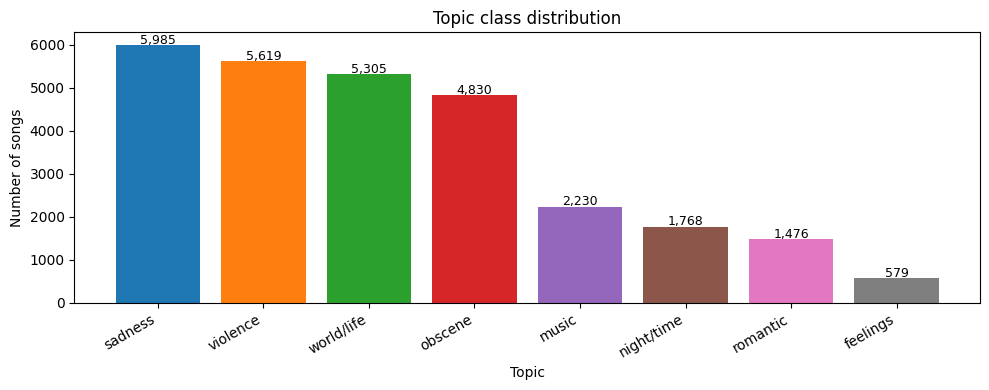

In [19]:
counts = df['topic'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = sns.color_palette('tab10', len(counts))
ax.bar(counts.index, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=9)
ax.set_xlabel('Topic')
ax.set_ylabel('Number of songs')
ax.set_title('Topic class distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'topic_distribution.png'), dpi=120)
plt.show()

## 9. Stratified 80/20 train/test split

In [20]:
KEEP_COLS = ['artist_name', 'track_name', 'release_date', 'genre',
             'lyrics_clean', 'topic', 'topic_label']

df_out = df[KEEP_COLS].copy()

train_df, test_df = train_test_split(
    df_out,
    test_size=0.2,
    random_state=42,
    stratify=df_out['topic_label'],
)

train_path = os.path.join(DATA_DIR, 'train.csv')
test_path  = os.path.join(DATA_DIR, 'test.csv')
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path,  index=False)

print(f'Train: {len(train_df):,} rows  →  {train_path}')
print(f'Test : {len(test_df):,} rows  →  {test_path}')
print()
print('Train class distribution:')
print(train_df['topic'].value_counts().sort_index().to_string())
print('\nTest class distribution:')
print(test_df['topic'].value_counts().sort_index().to_string())

Train: 22,233 rows  →  /Users/nidhijadhav/Desktop/cs4120/lyrics-to-valence/data/processed/train.csv
Test : 5,559 rows  →  /Users/nidhijadhav/Desktop/cs4120/lyrics-to-valence/data/processed/test.csv

Train class distribution:
topic
feelings       463
music         1784
night/time    1414
obscene       3864
romantic      1181
sadness       4788
violence      4495
world/life    4244

Test class distribution:
topic
feelings       116
music          446
night/time     354
obscene        966
romantic       295
sadness       1197
violence      1124
world/life    1061
